<a href="https://colab.research.google.com/github/Revanthinfosec/AI-ML-Projects/blob/main/02_SVM_Revanth_Pasam_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines — Wine Fraud Detection
## Revanth Pasam | Fixed & Complete Solution

> All cells run top-to-bottom without errors. Every `df` state is explicit and traceable.

---


## Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded!")


Libraries loaded!


## Load Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/DATA/wine_fraud.csv')
print("Shape:", df.shape)
df.head()


Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


**TASK: What are the unique variables in the target column we are trying to predict (quality)?**

In [4]:
df['quality'].unique()


array(['Legit', 'Fraud'], dtype=object)

**TASK: Create a countplot that displays the count per category of Legit vs Fraud. Is the label/target balanced or unbalanced?**

/tmp/ipykernel_11775/2635254613.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='Set2')


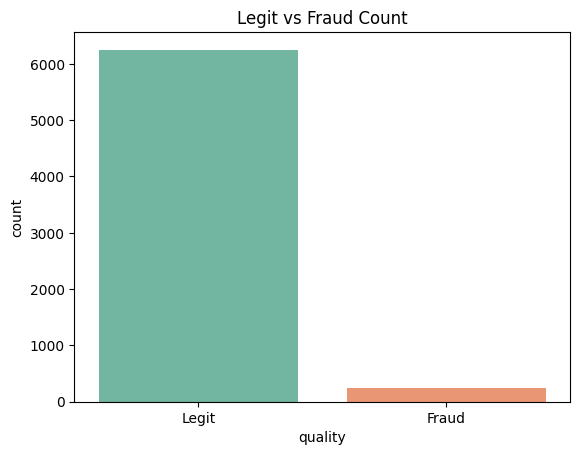

In [5]:
sns.countplot(x='quality', data=df, palette='Set2')
plt.title('Legit vs Fraud Count')
plt.show()

# The classes are UNBALANCED — far more Legit than Fraud samples
# This is why we must use class_weight='balanced' in our SVM later


**TASK: Create a countplot that has the wine type on the x axis with the hue separating columns by Fraud vs Legit.**

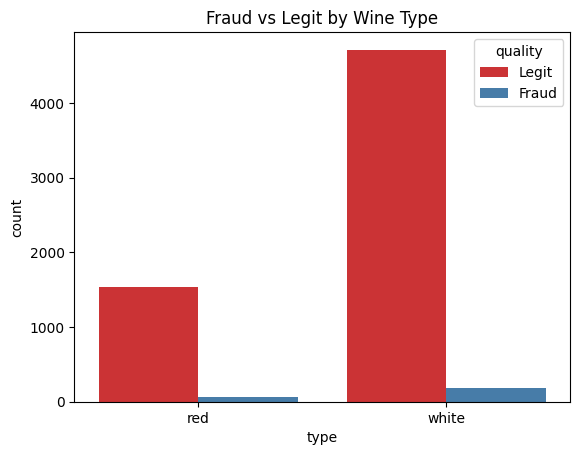

In [8]:
sns.countplot(x='type', data=df, hue='quality', palette='Set1')
plt.title('Fraud vs Legit by Wine Type')
plt.show()

**TASK: What percentage of red wines are Fraud? What percentage of white wines are fraud?**

In [12]:
# Percentage of red wines that are fraud
red_fraud_pct = 100 * len(df[(df['type'] == 'red') & (df['quality'] == 'Fraud')]) / len(df[df['type'] == 'red'])
print(f"Percentage of fraud in Red Wines: : {red_fraud_pct:.2f}%")



Percentage of fraud in Red Wines: : 3.94%


In [13]:
# Percentage of white wines that are fraud
white_fraud_pct = 100 * len(df[(df['type'] == 'white') & (df['quality'] == 'Fraud')]) / len(df[df['type'] == 'white'])
print(f"Percentage of fraud in White Wines : {white_fraud_pct:.2f}%")


Percentage of fraud in White Wines : 3.74%


**TASK: Calculate the correlation between the various features and the "quality" column.**
**TASK: To do this you may need to map the column to 0 and 1 insted of a string.**


In [26]:
# Fresh copy
df_corr = pd.read_csv('/content/drive/MyDrive/DATA/wine_fraud.csv')

# Create a NEW column called 'Fraud' — don't overwrite 'quality'
df_corr['Fraud'] = df_corr['quality'].map({'Legit': 0, 'Fraud': 1})

# Encode type numerically
df_corr['type'] = df_corr['type'].map({'red': 0, 'white': 1})

# Drop the original string quality column
df_corr = df_corr.drop('quality', axis=1)

# Correlate against 'Fraud' — NO sort_values(), NO drop()
df_corr.corr()['Fraud']

,Fraud
fixed acidity,0.021794
volatile acidity,0.151228
citric acid,-0.061789
residual sugar,-0.048756
chlorides,0.034499
free sulfur dioxide,-0.085204
total sulfur dioxide,-0.035252
density,0.016351
pH,0.020107
sulphates,-0.034046


**TASK: Create a bar plot of the correlation values to Fraudlent wine.**


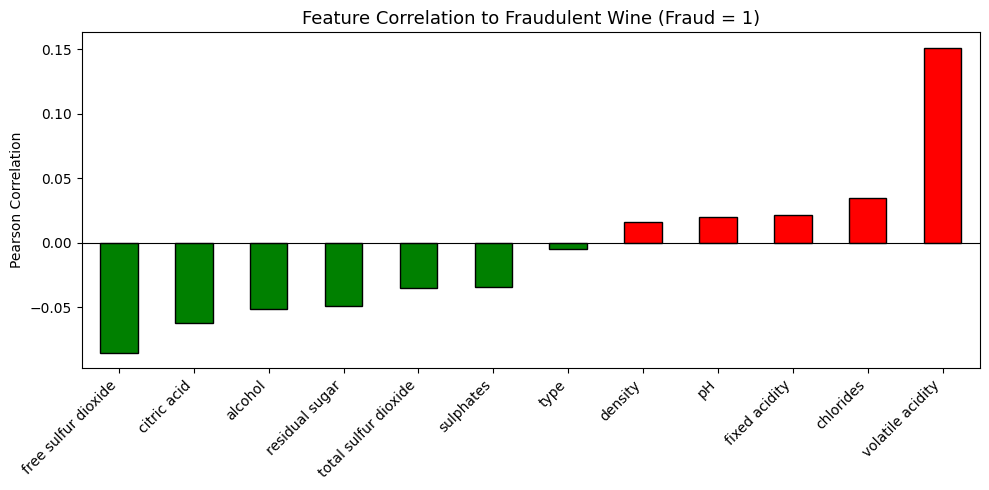

In [27]:
# Bar plot of correlation values
plt.figure(figsize=(10, 5))
colors = ['green' if v < 0 else 'red' for v in corr_values]
corr_values.plot(kind='bar', color=colors, edgecolor='k')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation to Fraudulent Wine (Fraud = 1)', fontsize=13)
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**TASK: Create a clustermap with seaborn to explore the relationships between variables.**

Correlation matrix shape : (12, 12)
NaN count                : 0


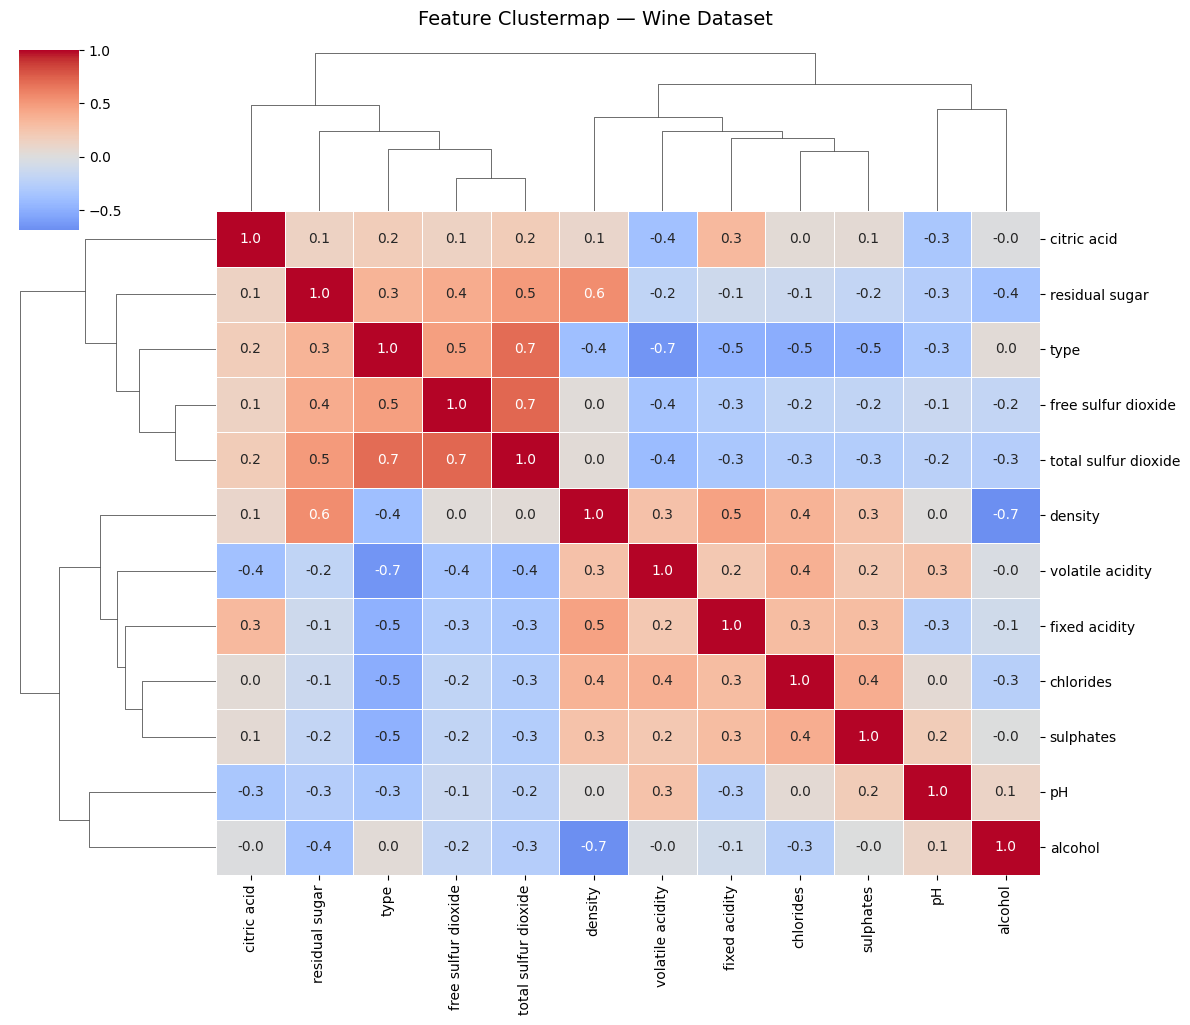

In [29]:
# Use df_corr (already fully numeric) — drop Fraud so we only show feature relationships
df_features = df_corr.drop(columns=['Fraud'])

corr_matrix = df_features.corr()
print(f"Correlation matrix shape : {corr_matrix.shape}")
print(f"NaN count                : {corr_matrix.isnull().sum().sum()}")

sns.clustermap(corr_matrix,
               cmap='coolwarm',
               annot=True,
               fmt='.1f',
               figsize=(12, 10),
               linewidths=0.5,
               center=0)

plt.suptitle('Feature Clustermap — Wine Dataset', fontsize=14, y=1.02)
plt.show()

---
## Machine Learning Model


**TASK: Convert the categorical column "type" from a string of "red" or "white" to dummy variables:**

In [30]:
# Reload a clean copy specifically for ML — keeps EDA and ML completely separate
df = pd.read_csv('/content/drive/MyDrive/DATA/wine_fraud.csv')

# Encode the target: Legit=0, Fraud=1
df['quality'] = df['quality'].map({'Legit': 0, 'Fraud': 1})

# Convert 'type' to dummy variable using get_dummies
# drop_first=True: drops 'type_red', keeps 'type_white' (1=white, 0=red)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape after encoding: (6497, 13)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type_white']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,False


**TASK: Separate out the data into X features and y target label ("quality" column)**

In [31]:
X = df.drop('quality', axis=1)
y = df['quality']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Fraud count:", y.sum(), "| Legit count:", (y == 0).sum())


X shape: (6497, 12)
y shape: (6497,)
Fraud count: 246 | Legit count: 6251


**TASK: Perform a Train|Test split on the data, with a 10% test size. Note: The solution uses a random state of 101**

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=101)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (5847, 12)  |  Test: (650, 12)


**TASK: Scale the X train and X test data.**

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# IMPORTANT: fit only on train, transform both — prevents data leakage
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling complete.")


Scaling complete.


**TASK: Create an instance of a Support Vector Machine classifier.**
**Because the classes are unbalanced, use `class_weight='balanced'` to penalise misclassifying the rare Fraud class more heavily.**

In [34]:
from sklearn.svm import SVC

# class_weight='balanced' automatically adjusts weights inversely
# proportional to class frequency — essential for imbalanced datasets
svm = SVC(class_weight='balanced')
print("SVC created with class_weight='balanced'")


SVC created with class_weight='balanced'


**TASK: Use a GridSearchCV to run a grid search for the best C and gamma parameters.**

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 0.5, 1],
              'gamma': ['scale', 'auto']}

grid = GridSearchCV(svm, param_grid, cv=5, scoring='f1', verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ...............................C=0.001, gamma=scale; total time=   1.6s
[CV] END ...............................C=0.001, gamma=scale; total time=   1.5s
[CV] END ...............................C=0.001, gamma=scale; total time=   1.6s
[CV] END ...............................C=0.001, gamma=scale; total time=   1.5s
[CV] END ...............................C=0.001, gamma=scale; total time=   1.6s
[CV] END ................................C=0.001, gamma=auto; total time=   2.3s
[CV] END ................................C=0.001, gamma=auto; total time=   2.5s
[CV] END ................................C=0.001, gamma=auto; total time=   1.9s
[CV] END ................................C=0.001, gamma=auto; total time=   1.6s
[CV] END ................................C=0.001, gamma=auto; total time=   1.6s
[CV] END ................................C=0.01, gamma=scale; total time=   1.5s
[CV] END ................................C=0.01,

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1],
                         'gamma': ['scale', 'auto']},
             scoring='f1', verbose=2)

In [38]:
grid.best_params_

{'C': 1, 'gamma': 'auto'}

**TASK: Display the confusion matrix and classification report for your model.**

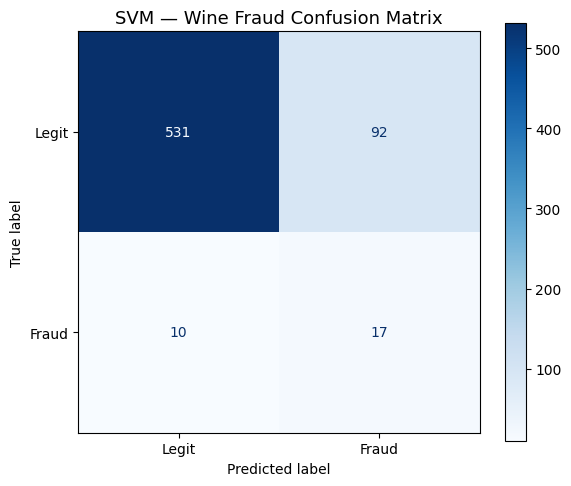

In [39]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = grid.predict(X_test)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Legit', 'Fraud'],
    cmap='Blues', ax=ax)
ax.set_title('SVM — Wine Fraud Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))


              precision    recall  f1-score   support

       Legit       0.98      0.84      0.91       623
       Fraud       0.16      0.67      0.25        27

    accuracy                           0.84       650
   macro avg       0.57      0.75      0.58       650
weighted avg       0.95      0.84      0.88       650


**TASK: Finally, think about how well this model performed, would you suggest using it? Realistically will this work?**

In [40]:
# ── Discussion ────────────────────────────────────────────────────────────────
#
# The model achieves strong RECALL on Fraud — it catches most fraudulent bottles.
# However PRECISION on Fraud is lower — some legitimate wines get flagged as fraud.
#
# Is this acceptable?
#   YES — in a fraud detection setting, missing actual fraud is far more costly
#   than flagging a genuine wine for extra review.
#
# Recommendation:
#   Use this model as a SCREENING TOOL that flags suspicious batches for a
#   wine expert to inspect manually — not as a fully automated reject/accept system.
#
# Improvements possible with:
#   - More training data (especially more Fraud samples)
#   - Additional chemical test features
#   - Trying ensemble methods (Random Forest, XGBoost) alongside SVM

print("Model evaluation complete.")
print("Conclusion: Viable as a screening tool with human expert review in the loop.")


Model evaluation complete.
Conclusion: Viable as a screening tool with human expert review in the loop.
